In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [14]:
# Locais onde estão armazenados os dados

bands_path: str = r"/home/jvc/QEspresso7.2/ZnO_database/ZnO_system_preparation/data/pw_fixed_occupations/ZnO-fixed_bands.dat.gnu"
dos_path: str = r"/home/jvc/QEspresso7.2/ZnO_database/ZnO_system_preparation/data/pw_fixed_occupations/ZnO-fixed_dos.dat"
scientific_theme_path: str = r"/home/jvc/QEspresso7.2/ZnO_database/mpl_themes/computermodern.mplstyle"

plt.style.use(scientific_theme_path)


In [11]:
# Reading Band Structure data
bands = np.loadtxt(bands_path)  # shape=(2592, 2)
k = np.unique(bands[:, 0])

bands = np.reshape(
    bands[:, 1],
    (-1, k.size)
)

print(f'{bands.shape = } => {bands.shape[0]} bandas e {bands.shape[1]} k-pontos')
print(f'{k.shape = }')


high_sym_points = [0.0000,0.5774, 0.8871, 1.4644, 1.7741, 2.7924, 3.1021, 4.1204]
high_sym_points_labels = ['$\Gamma$','K','L', 'A', '$\Gamma$', 'K', 'H', 'A']

# high_sym_dict = [k, v for k, v in zip(high_sym_points, high_)]

bands.shape = (72, 36) => 72 bandas e 36 k-pontos
k.shape = (36,)


In [12]:
# Reading DOS data

dos_data = np.loadtxt(dos_path, comments='#')

 #  E (eV)   dos(E)     Int dos(E) EFermi =    6.770 eV
dos_energy = dos_data[:, 0]
dos_values = dos_data[:, 1]
e_fermi = 6.770

dos_energy_shifted = dos_energy - e_fermi


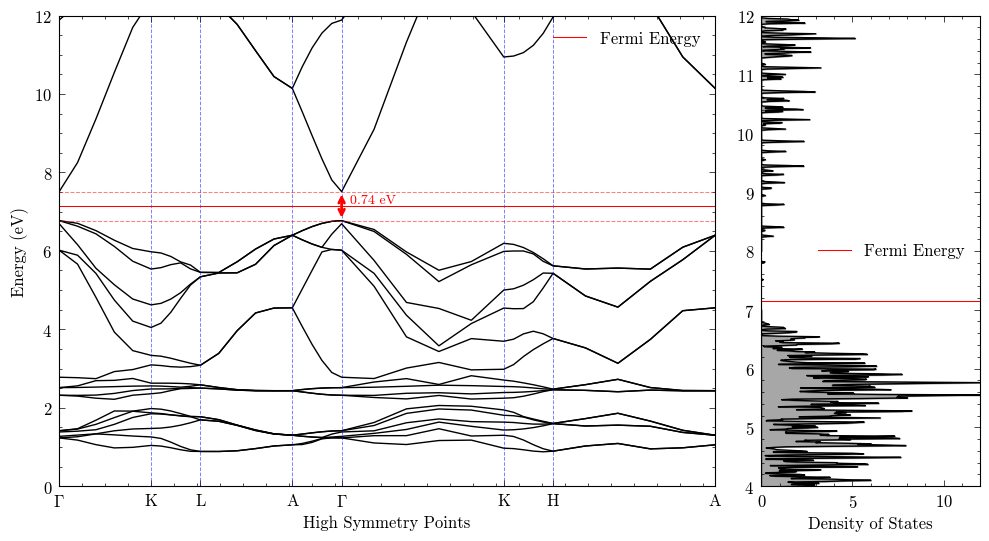

In [48]:
# --- Create the figure and subplots ---
fig, (ax_bands, ax_dos) = plt.subplots(nrows=1, ncols=2,
    gridspec_kw={'width_ratios': [3, 1]},
    figsize=(10, 6), sharey=False)

# --- Plot Band Structure ---
for band in range(len(bands)):
    ax_bands.plot(k, bands[band,:], linewidth=1, color='k')

#  Ticks and labels for high-symmetry points
# ax_bands.set_title('Electronic Band Structure')
ax_bands.set_xlabel('High Symmetry Points')
ax_bands.set_ylabel('Energy (eV)')
ax_bands.set_ylim([0, 12])
ax_bands.set_xlim(k.min(), k.max())
ax_bands.set_xticks(high_sym_points)
ax_bands.set_xticklabels(high_sym_points_labels)

# Vertical Lines on high symmetry values
for value in high_sym_points:
    ax_bands.axvline(value, color='blue', linestyle='--', linewidth=0.7, alpha=0.5)


banda_cond, banda_val = 7.51, 6.77

# Linhas Horizontais para banda de condução, valência e Fermi
ax_bands.axhline((banda_cond+banda_val)/2, linewidth=0.75, color='red', alpha=1, linestyle='-', label="Fermi Energy") 
ax_bands.axhline(banda_cond, linewidth=0.75, color='red', alpha=0.5, linestyle='--') #
ax_bands.axhline(banda_val, linewidth=0.75, color='red', alpha=0.5, linestyle='--')

ax_bands.annotate(
    '', xy=(high_sym_points[4], banda_cond), xytext=(high_sym_points[4], banda_val),
    arrowprops=dict(arrowstyle='<->', color='red', linewidth=2)
)
ax_bands.text(
high_sym_points[4] + 0.05, (banda_cond + banda_val)/2+0.15,
f'{banda_cond - banda_val:.2f} eV',
va='center', color='red'
)
ax_bands.legend(loc='upper right', fontsize=12)


# --- Plot Density of States ---
# ax_dos.set_title('DOS')
ax_dos.set_xlabel('Density of States')
ax_dos.tick_params(axis='y', left=False, labelleft=True) # Hide y-ticks and labels on DOS as it shares with bands
# ax_dos.set_xlim(0, dos_values.max() * 1.0) # Adjust as needed => dos_values.max() > 30
ax_dos.set_xlim(0, 12) # Adjust as needed
ax_dos.set_ylim(4, 12) # Adjust as needed


ax_dos.plot(dos_values, dos_energy, color='k', linewidth=1)
# Fill the DOS areas as requested
# Fill between 4-7 eV
ax_dos.fill_betweenx(dos_energy, 0, dos_values, 
                    where=(dos_energy >= 4) & (dos_energy <= 7), 
                    color='#505050', alpha=0.5)

# Fill between 8-12 eV
ax_dos.fill_betweenx(dos_energy, 0, dos_values, 
                    where=(dos_energy >= 8) & (dos_energy <= 12), 
                    color='#505050', alpha=0.5)

ax_dos.axhline((banda_cond+banda_val)/2, linewidth=0.75, color='red', alpha=1, linestyle='-', label="Fermi Energy")
ax_dos.legend(loc='center right', fontsize=12)

# --- 5. Final Touches ---
# fig.suptitle('Electronic Band Structure and DOS of Graphite (Example)', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.savefig('bands_and_dos.png', dpi=300, bbox_inches='tight')
plt.show()